# Training the stream-cleaning/detection U-Net, step by step

This notebook builds on `create_data.ipynb`: it reuses the same background +
matched-filter + `StreamInjector` construction, then wires up the rest of the
pipeline -- `StreamMapDataset`, `StreamMapTransform`/`RobustNormalizer`,
`models.unet.UNet`, `models.losses`, `training.plain_runner.PlainTrainer`, and
`evaluation/` -- and runs one short **real** training loop end to end.

`label_policy="stream_detection"` (PLAN.md §6.12): the network is trained to
output, per pixel, a probability that a real stream detection sits there
(`stream_raw > count_threshold`), not a literal star count. An earlier
version of this notebook trained `label_policy="stream_count"` (literal
counts) directly -- it localized streams well but persistently
under-recovered their peak amplitude by a large factor (see
{doc}`../narrative/ml_concepts` for why); retargeting at the bounded
detection label sidesteps that problem entirely rather than fighting it.

This is a smoke-scale run (few epochs, few steps per epoch) -- it proves the
whole pipeline trains and evaluates for real, not a scientifically tuned
model. Scaling up (more steps/epochs, a richer eval grid, GPU, the
`training/hyrax_runner.py` orchestration layer) is future work.

In [1]:
import tempfile

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skyproj
import torch
from torch.utils.data import DataLoader

from streamgoggles.background import Background
from streamgoggles.background_sources import StreamObsLightBackgroundSource, StudyRegion
from streamgoggles.config import (
    DistributionType,
    ParameterSpec,
    StreamConfig,
    build_eval_grid,
)
from streamgoggles.data_preparation import Cut
from streamgoggles.datasets.stream_map_dataset import (
    StreamMapDataset,
    TransformedDataset,
    configure_torch_threads,
    default_num_workers,
    stream_map_collate_fn,
)
from streamgoggles.datasets.transforms import RobustNormalizer, StreamMapTransform
from streamgoggles.evaluation.baseline_threshold import build_baseline
from streamgoggles.evaluation.completeness_purity import (
    aggregate_over_replicates,
    evaluate_on_grid,
    plot_recovery_vs_parameter,
)
from streamgoggles.evaluation.footprint import (
    THRESHOLD_GRID,
    detection_metrics,
    evaluate_footprint_realizations,
    plot_confusion_matrix,
    plot_detection_metrics,
    plot_detection_rates,
    predict_footprint,
    tiles_around_stream,
)
from streamgoggles.evaluation.metrics import dice, iou
from streamgoggles.injector import StreamInjector
from streamgoggles.matched_filter import (
    PixelizationSpec,
    ColorBoxFilter,
    StreamobsSplineFilter,
    crop_window,
    stitch_windows_to_healpix,
)
from streamgoggles.models.losses import get_loss
from streamgoggles.models.unet import UNet
from streamgoggles.storage import BackgroundMapStore, ModelStore, SimulationStore
from streamgoggles.stream_sources import StreamObsSource
from streamgoggles.training.plain_runner import PlainTrainer
from streamgoggles.windows import tile_footprint

%matplotlib inline


## 1. Configuration

Background/matched-filter/window config mirrors `create_data.ipynb`, with
`nside=512` (the standard resolution for stream search, PLAN.md §6.12) and
`pixel_scale_deg` never set by hand (auto-derived from `nside` alone).
`image_size_pix` (a separate, independent choice from `nside`) is kept
modest for training-loop speed -- per-sample generation cost is dominated
by the background catalog's own selection/injection cost, not by window
pixel count (verified for real: ~1s/sample regardless of `image_size_pix`
at fixed catalog size), so this choice is really about keeping the model's
own compute small, not about generation speed.

`count_threshold=1.0` (`StreamInjector`'s own default, PLAN.md §6.13) --
not the `count_threshold=10.0` an earlier version of this notebook used.
That value made `label_policy="stream_detection"`'s label entirely empty
for `surface_brightness` fainter than ~31 at this `nside`/geometry, which
directly conflicts with this project's real observational range (streams
already detected down to SB 33, with an ambition to reach 34-35).
`count_threshold=1.0` is the lowest threshold that keeps a non-empty label
all the way to SB 35, at this `nside`/geometry -- see `create_data.ipynb`'s
"Calibrating count_threshold empirically" section (§4) for the full sweep and
reasoning, and PLAN.md §6.13 for the decision log. An earlier version of this
notebook paid for that choice with a decoy channel whose label picked up real
stream stars at the bright end (a third of the good channel's at SB 31); the
fixed decoy box used here (a plain colour-magnitude box at absolute limits,
§1's `filters_cfg`) selects none at any surface brightness, so the cost is
gone.

`stream_param_cfg["richness"] = [32.0, 33.0, 33.5, 34.0, 34.5]`
(surface_brightness, DISCRETE -- an eval grid point per value, PLAN.md §6.13):
the range brackets the SB 33-34 target rather than matching it, which the
hyperparameter experiment found is what decides where detections stop (docs:
"Experiments and tests"). Every point produces a genuinely non-empty label
under this notebook's `clipping_cfg`. Whether SB 34 -- the faintest, thinnest-labeled point
-- is recovered well by the network, or needs more training budget/a
different threshold, is exactly what §7's per-richness Dice curve below is
for.

In [2]:
SEED = 42

study_region_cfg = dict(center_ra=0.0, center_dec=-30.0, width_deg=25.0, height_deg=18.0)

# Magnitude limits live ONLY in clipping_cfg: stars outside [min, max] in any
# band are dropped, from the background catalog and from every injected
# stream alike. cuts_cfg is kept for quality cuts that are not magnitude
# ranges (SNR, star/galaxy separation, a custom function -- see
# data_preparation.Cut), which real data will need; none are used here.
# (Magnitude cuts g < 26.5, r < 26 used to sit here too; clipping at 25 already
# removed every star they would have, so dropping them changes nothing.)
cuts_cfg = []
clipping_cfg = {"g": {"min": 16.0, "max": 24.5}, "r": {"min": 16.0, "max": 24.5}}

background_cfg = dict(
    source="light",
    survey="lsst",
    release="yr1",
    # seed is NOT decoration: streamobs's synthetic background generation is
    # unseeded by default, so without this every run of this notebook trains
    # on a *different* background catalog -- two loads in one process differ,
    # and numpy's global seed has no effect on it (PLAN.md §6.15). That was
    # the real cause of this notebook's run-to-run metric variation.
    source_kwargs={"seed": 20260915},
    finalize={"enabled": False},
)

filters_cfg = dict(
    good=dict(type="isochrone", reference_isochrone=dict(age=12.5, z=0.0002)),
    # A deliberately wrong filter: a fixed colour-magnitude box, redder than any
    # isochrone in the catalog, with absolute limits instead of an offset from
    # the good filter's polygon. Fixed means the decoy channel selects the same
    # region of colour-magnitude space in every sample, at every trial distance
    # and in every experiment, so the network always sees the same negative
    # control. The magnitude range starts at 18 rather than 16: below that the
    # catalog is saturated and the box would select almost nothing.
    decoy=dict(type="box", color_range=(1.2, 1.5), mag_range=(18.0, 24.5)),
)

# nside=512, pixel_scale_deg auto-derived (never set by hand) -- see §1.
matched_filter_cfg = dict(
    bands=["g", "r"],
    pixelization=dict(nside=512, image_size_pix=(96, 96)),
    distance_moduli=[16.0,],
)

window_cfg = dict(min_stream_length_deg=5.0, max_attempts=100)

# count_threshold: label_policy="stream_detection"'s per-pixel star-count
# cut (§2) -- a pixel is a "detection" once its true stream-only count
# exceeds this. 1.0 is StreamInjector's own default, calibrated
# empirically (PLAN.md §6.13) -- see §1 markdown above.
count_threshold = 1.0

stream_param_cfg = dict(
    morphology="uniform",
    richness=[32.0, 33.0, 33.5, 34.0, 34.5],  # DISCRETE surface_brightness (mag/arcsec^2) -- see §1
    width=0.2,
    length=8.0,
    distance_modulus=16.,  # matches a trial distance in matched_filter_cfg
    age=12.5,
    z=0.0002,
)

# Independent realizations per eval-grid point (§7). Each parameter
# combination is evaluated n_eval_replicates times with different
# placement/window/orientation/noise, so a per-richness metric is a mean and
# spread rather than one arbitrary draw of it -- see §7/§8.
n_eval_replicates = 5

model_cfg = dict(base_width=12, depth=2, head="sigmoid")

# Training range and length come from the hyperparameter experiment (docs:
# "Experiments and tests" > "Hyperparameters"). Two results set them:
#  - the training surface brightness range decides where detections stop, so
#    it brackets the target (33-34) instead of matching it: 32 to 34.5;
#  - training length is a real gain, but only visible at a matched false-alarm
#    rate: at a background density of 1e-3, SB 33.5 detection goes 31% (1200
#    windows) -> 44% (4800) -> 60% (19200). 4800 windows is the compromise
#    used here; 19200 is better and four times the cost.
# steps_per_epoch counts training WINDOWS, so 40 x 120 = 4800 windows, and
# batch 8 means 15 optimizer steps per epoch.
#
# Loss, batch size and background fraction come from the loss-selection
# experiment (docs: "Experiments and tests" > "Loss selection"): batch Dice at
# batch 8 gave the highest contrast at a fixed threshold and the widest range
# of thresholds to tune the maps with; background_fraction 0.05 made no
# measurable difference against 0.3.
train_cfg = dict(
    epochs=40,
    steps_per_epoch=120,
    batch_size=8,
    lr=2e-3,
    background_fraction=0.05,
    loss_name="batch_dice",
)

namespace = f"{background_cfg['survey']}_{background_cfg['release']}"

## 2. Build background + matched filters + injector

Exactly `create_data.ipynb` §2.2-2.3 and §3 -- see that notebook for the
step-by-step breakdown of what `StreamInjector.inject_single_stream` does
internally.


In [3]:
study_region = StudyRegion(**study_region_cfg)
pix = PixelizationSpec(**matched_filter_cfg["pixelization"])

matched_filters = {}
for name, cfg in filters_cfg.items():
    if cfg["type"] == "isochrone":
        matched_filters[name] = StreamobsSplineFilter(
            iso_config=cfg["reference_isochrone"], namespace=namespace
        )
    elif cfg["type"] == "box":
        matched_filters[name] = ColorBoxFilter(
            color_range=cfg["color_range"],
            mag_range=cfg["mag_range"],
            namespace=namespace,
        )
    else:
        raise ValueError(f"unknown filter type {cfg['type']!r}")

cuts = [Cut(**c) for c in cuts_cfg]
bg_store = BackgroundMapStore(tempfile.mkdtemp(prefix="streamgoggles_train_bgmaps_"))

background = Background.load_or_cache(
    source=StreamObsLightBackgroundSource(),
    source_cfg=background_cfg["source_kwargs"],
    study_region=study_region,
    cuts=cuts,
    clipping=clipping_cfg,
    matched_filters=matched_filters,
    bands=matched_filter_cfg["bands"],
    distance_moduli=matched_filter_cfg["distance_moduli"],
    finalize_cfg=background_cfg["finalize"],
    store=bg_store,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    filter_configs=filters_cfg,
)

n_channels = len(matched_filter_cfg["distance_moduli"]) * len(matched_filters)
print(f"background catalog: {len(background.catalog)} stars (after cuts+clipping)")
print(f"n_channels = n_distances * n_filters = {n_channels}")


Loading survey data for 'lsst_yr1'...
  Loading config from: lsst_yr1.yaml

LOADING SURVEY DATA FILES
Survey data directory: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/surveys/lsst_yr1

Fallback directory for shared data files: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/others

Available bands: g, i, r, u, y, z


Loading survey properties...
Loading magnitude limit maps...
  ✓ Success for g-band magnitude limit
  ⚠ Warning: 'maglim_map_i' not specified in config (skipping i-band)
  ✓ Success for r-band magnitude limit
  ⚠ Warning: 'maglim_map_u' not specified in config (skipping u-band)
  ⚠ Warning: 'maglim_map_y' not specified in config (skipping y-band)
  ⚠ Warning: 'maglim_map_z' not specified in config (skipping z-band)

Loading completeness/efficiency function...
  Loading Completeness/efficiency function...
    File: lsst_dc2_stellar_efficiency_cutr.csv
    ✓ Success
  Loading Detection efficiency function...
    File: lsst_dc

/Users/pelissier/Documents/Codes/packages/streamobs/streamobs/background/background.py:159: UserWarning: Requested nside=4096 exceeds the magnitude-limit map resolution (nside=128). Capping to nside=128.
  return gen.generate(


background catalog: 2598390 stars (after cuts+clipping)
n_channels = n_distances * n_filters = 2


In [4]:
injector = StreamInjector(
    background=background,
    matched_filters=matched_filters,
    stream_source=StreamObsSource(),
    cuts=cuts,
    clipping=clipping_cfg,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    bands=tuple(matched_filter_cfg["bands"]),
    richness_kind="surface_brightness",
    finalize_cfg=background_cfg["finalize"],
    label_policy="stream_detection",
    count_threshold=count_threshold,
)
injector

✓ Using cached survey data for 'lsst_yr1'


## 3. `StreamConfig` and the training/eval datasets

`StreamMapDataset` in training mode (`eval_mode=False`) generates a fresh
sample on every `__getitem__` call -- a mix of real injected streams and
(with probability `background_fraction`) pure-background windows. In eval
mode it walks a fixed, persisted grid: since `richness` is the only DISCRETE
parameter here, that grid has exactly `len(stream_param_cfg["richness"])`
points, one per richness value.


In [5]:
params = {
    "morphology": ParameterSpec(
        name="morphology", dist_type=DistributionType.FIXED, value=stream_param_cfg["morphology"]
    ),
    "richness": ParameterSpec(
        name="richness", dist_type=DistributionType.DISCRETE, values=stream_param_cfg["richness"]
    ),
    "width": ParameterSpec(name="width", dist_type=DistributionType.FIXED, value=stream_param_cfg["width"]),
    "length": ParameterSpec(name="length", dist_type=DistributionType.FIXED, value=stream_param_cfg["length"]),
    "distance_modulus": ParameterSpec(
        name="distance_modulus", dist_type=DistributionType.FIXED, value=stream_param_cfg["distance_modulus"]
    ),
    "age": ParameterSpec(name="age", dist_type=DistributionType.FIXED, value=stream_param_cfg["age"]),
    "z": ParameterSpec(name="z", dist_type=DistributionType.FIXED, value=stream_param_cfg["z"]),
}
stream_config = StreamConfig(
    params=params,
    background_fraction=train_cfg["background_fraction"],
    persist=False,
    richness_kind="surface_brightness",
)

sim_store = SimulationStore(tempfile.mkdtemp(prefix="streamgoggles_train_sims_"))

train_dataset = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    store=sim_store,
    eval_mode=False,
    steps_per_epoch=train_cfg["steps_per_epoch"],
    rng=np.random.default_rng(SEED),
)
# Per-epoch validation grid: one realization per richness value. Kept at
# one replicate deliberately -- it runs every epoch, and its job is a
# comparable-across-epochs learning signal, not a statistically solid score.
eval_dataset = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    store=sim_store,
    eval_mode=True,
)

# Final-evaluation grid (§7): the same richness values, each with
# n_eval_replicates independent realizations. Generated once, not per epoch,
# so the extra cost is a handful of seconds rather than a per-epoch tax.
eval_dataset_multi = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    eval_mode=True,
    eval_grid=build_eval_grid(stream_config, n_replicates=n_eval_replicates),
    # Its OWN store, deliberately: SimulationStore addresses samples by
    # params, and this grid's replicate-0 entries would otherwise share a
    # cache key with the per-epoch grid above while asking for a different
    # seed -- whichever generated first would silently win, ignoring the
    # other's seed.
    store=SimulationStore(tempfile.mkdtemp(prefix="streamgoggles_eval_multi_sims_")),
)
print(f"train_dataset: {len(train_dataset)} samples/epoch (on the fly, never repeated)")
print(f"eval_dataset: {len(eval_dataset)} samples (1 realization per richness, used every epoch)")
print(
    f"eval_dataset_multi: {len(eval_dataset_multi)} samples "
    f"({n_eval_replicates} realizations per richness, used once in §7)"
)


train_dataset: 120 samples/epoch (on the fly, never repeated)
eval_dataset: 5 samples (1 realization per richness, used every epoch)
eval_dataset_multi: 25 samples (5 realizations per richness, used once in §7)


### 3.1 Fit a normalizer, wrap both datasets with `StreamMapTransform`

`RobustNormalizer.fit()` wants pooled statistics; a handful of pre-drawn
training samples, concatenated along the spatial axis, is enough for this
smoke-scale run. Only `map_stack` (the input) gets normalized -- `label_stack`
is never normalized, whatever scale it's actually in (already bounded `{0,
1}` under `label_policy="stream_detection"`). Training gets `augment=True`
(flips/90-degree rotations); eval stays `augment=False` for reproducibility.

In [6]:
fit_samples = [train_dataset[i] for i in range(8)]
pooled_map_stack = np.concatenate([s["map_stack"] for s in fit_samples], axis=1)
pooled_valid_mask = np.concatenate([s["valid_mask"] for s in fit_samples], axis=0)

normalizer = RobustNormalizer()
normalizer.fit(pooled_map_stack, pooled_valid_mask)
print(f"per-channel mean: {normalizer.mean}")
print(f"per-channel std:  {normalizer.std}")

train_transform = StreamMapTransform(normalizer=normalizer, augment=True, rng=np.random.default_rng(SEED + 1))
eval_transform = StreamMapTransform(normalizer=normalizer, augment=False)

train_dataset_norm = TransformedDataset(train_dataset, train_transform)
eval_dataset_norm = TransformedDataset(eval_dataset, eval_transform)
eval_dataset_multi_norm = TransformedDataset(eval_dataset_multi, eval_transform)


per-channel mean: [ 9.0123415  10.55836391]
per-channel std:  [2.08683515 2.26999164]


### 3.2 Bias initialization: start near the true class prior, not near zero

`label_policy="stream_detection"`'s target is already bounded (`{0, 1}`) and
class-imbalanced -- most pixels are background (0), only a real stream's
own pixels are positive -- rather than heavy-tailed and unbounded the way
`label_policy="stream_count"`'s literal counts were (which needed the
`log1p`-space training + `expm1`-unwrapping this notebook used to use; not
needed here, since there's no large dynamic range to compress).

What's still real and still needed: **data-informed bias initialization**,
same technique, adapted to a classification target. With `head="sigmoid"`,
the default (near-zero) initialization starts the model predicting ~0.5
probability everywhere -- not wrong exactly, but not informed by how rare
positive pixels actually are either, and (confirmed empirically, same as
the `stream_count` version of this notebook) an uninformed start burns a
chunk of an already-modest training budget just moving the *overall* output
scale to somewhere sensible, before it can spend the rest learning *where*
the positive pixels are. The classification analogue of "start near the
target's own scale" is to initialize the head's bias to the **logit of the
per-channel positive-pixel fraction**, `log(p / (1 - p))` -- so the model
starts out predicting close to the empirical prior everywhere, uniformly,
and only has to learn the *spatial* pattern from there (exactly what the
zeroed head weight below leaves it to do).

In [7]:
# eps keeps the logit finite even if a channel's fit_samples happened to
# show exactly 0 (or 1) positive fraction.
_eps = 1e-3
pos_frac = np.array(
    [
        np.mean([s["label_stack"][c][s["valid_mask"]].mean() for s in fit_samples])
        for c in range(n_channels)
    ]
)
pos_frac_clamped = np.clip(pos_frac, _eps, 1 - _eps)
bias_init = np.log(pos_frac_clamped / (1 - pos_frac_clamped)).astype(np.float32)
print(f"per-channel positive-pixel fraction: {pos_frac}")
print(f"per-channel bias-init (logit of that fraction): {bias_init}")

per-channel positive-pixel fraction: [0.02316719 0.        ]
per-channel bias-init (logit of that fraction): [-3.7415783 -6.906755 ]


## 4. Model, loss, optimizer, trainer

`in_channels`/`out_channels` = `n_channels` (§2): one channel per
`(filter, distance)` pair. `head="sigmoid"` gives a genuine per-pixel
probability in `(0, 1)` at every output position -- see
{doc}`../narrative/ml_concepts`/{doc}`../narrative/datasets_and_models` for
why this is true regardless of the label being a hard `{0, 1}` target.

`loss_name="batch_dice"` (`models.losses.BatchDiceLoss`) with
`batch_size=8`. Plain Dice computes one overlap ratio per window, so a window
without any stream gets essentially no gradient: nothing teaches the model to
predict low there. Batch Dice pools the sums over the whole batch before
taking the ratio, so a false alarm in a stream-free window costs the same as
one next to a stream. It was selected by comparing 9 loss / batch size /
background fraction configurations, 4 seeds each, on completeness,
contamination and contrast at a fixed threshold (docs: "Experiments and
tests" > "Loss selection").


In [8]:
torch.manual_seed(SEED)
model = UNet(in_channels=n_channels, out_channels=n_channels, **model_cfg)

# Data-informed bias init (§3.2): start the model's output at the
# per-channel class prior instead of the default near-zero-logit init.
with torch.no_grad():
    model.head_conv.bias.copy_(torch.from_numpy(bias_init))
    model.head_conv.weight.zero_()

optimizer = torch.optim.Adam(model.parameters(), lr=train_cfg["lr"])
loss_fn = get_loss(train_cfg["loss_name"])
trainer = PlainTrainer(model=model, optimizer=optimizer, loss_fn=loss_fn, device="cpu")
sum(p.numel() for p in model.parameters())

67058

## 5. Train

`train_cfg["epochs"] * train_cfg["steps_per_epoch"] = 1200` training windows,
each generated fresh and never reused, split into batches of 8 (so ~150
optimizer steps in total). The loss-selection experiment trained with exactly
this budget; batch 8 takes 4 times fewer optimizer steps than batch 2 for the
same number of windows, so a longer training may still help -- that is part of
the planned hyperparameter experiment.


In [9]:
# Sample generation is CPU-bound and single-threaded, so workers overlap it
# with training: 0.119 -> 0.049 s/sample measured here (PLAN.md §6.18).
# default_num_workers() deliberately does NOT take the whole machine and
# honors a SLURM allocation / cpuset rather than the physical core count, so
# this same line is safe to run on a cluster; STREAMGOGGLES_NUM_WORKERS
# overrides it. persistent_workers is what makes it worth enabling at all --
# without it, worker startup (~12s under macOS/Windows "spawn"; ~0 under
# Linux "fork") is paid EVERY epoch instead of once.
num_workers = default_num_workers()
# Cap torch's intra-op threads. It otherwise claims EVERY core (8 of 10
# here) on top of the DataLoader workers, which oversubscribes the machine
# for almost no gain -- the model step is ~24ms against ~130ms of sample
# generation. It is also load-bearing in this environment: two libomp copies
# end up loaded in one process, and torch's first convolution after that
# segfaults inside pthread_create unless it stays single-threaded
# (PLAN.md §6.19).
torch_threads = configure_torch_threads(num_workers=num_workers)
loader_kwargs = dict(collate_fn=stream_map_collate_fn, num_workers=num_workers)
if num_workers > 0:
    loader_kwargs["persistent_workers"] = True
print(f"DataLoader workers: {num_workers}, torch intra-op threads: {torch_threads}")

train_dl = DataLoader(
    train_dataset_norm, batch_size=train_cfg["batch_size"], **loader_kwargs
)
val_dl = DataLoader(
    eval_dataset_norm, batch_size=train_cfg["batch_size"], **loader_kwargs
)

model_store = ModelStore(tempfile.mkdtemp(prefix="streamgoggles_train_models_"))
model_config = dict(in_channels=n_channels, out_channels=n_channels, **model_cfg)
run_config = {
    "model_config": model_config,
    "loss_name": train_cfg["loss_name"],
    "label_policy": "stream_detection",
    "count_threshold": count_threshold,
    "seed": SEED,
}

result = trainer.train(
    train_dl,
    val_dl=val_dl,
    epochs=train_cfg["epochs"],
    model_store=model_store,
    config=run_config,
    save_every=train_cfg["epochs"],
)
print(f"epochs_run={result['epochs_run']}")
print(f"train_losses={result['train_losses']}")
print(f"val_losses={result['val_losses']}")
print(f"final_checkpoint_path={result['final_checkpoint_path']}")

DataLoader workers: 4, torch intra-op threads: 1


epochs_run=40
train_losses=[0.9723320206006368, 0.8726300040880839, 0.8142574350039165, 0.8232503175735474, 0.8310588598251343, 0.8228018045425415, 0.7647130966186524, 0.806174119313558, 0.7785438617070516, 0.7832756400108337, 0.8006344556808471, 0.7809810042381287, 0.7659982164700826, 0.7265628139177959, 0.7452702681223552, 0.7527757128079732, 0.7621793190638224, 0.7736157496770223, 0.7216322541236877, 0.7210740963617961, 0.7288544495900472, 0.7443958004315694, 0.7255224148432414, 0.7523744424184163, 0.7434026996294657, 0.7499093890190125, 0.7037552038828532, 0.6841381390889486, 0.7309834917386373, 0.7261622428894043, 0.7312654654184977, 0.7847408294677735, 0.7232981085777282, 0.7393528103828431, 0.7152882655461629, 0.7048813223838806, 0.7118860562642415, 0.7300530076026917, 0.6892662048339844, 0.7045893589655559]
val_losses=[0.9594255089759827, 0.8346270322799683, 0.8131672143936157, 0.8186481595039368, 0.8033605813980103, 0.7842146158218384, 0.7844669222831726, 0.8230997920036316, 0

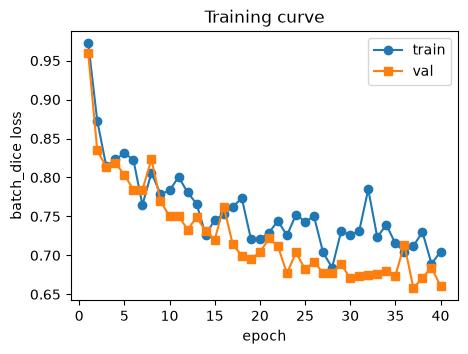

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.5))
epochs_axis = np.arange(1, train_cfg["epochs"] + 1)
ax.plot(epochs_axis, result["train_losses"], marker="o", label="train")
ax.plot(epochs_axis, result["val_losses"], marker="s", label="val")
ax.set_xlabel("epoch")
ax.set_ylabel(f"{train_cfg['loss_name']} loss")
ax.set_title("Training curve")
ax.legend()
plt.show()

## 6. Inspect one prediction

**Which sample is this?** `eval_dataset_norm[inspect_idx]` below -- a
**validation** sample from the fixed eval grid (§3), *not* a training
sample. Worth being precise about what that does and doesn't mean here,
because it isn't a conventional train/test split:

- Training samples are generated fresh on every step and never reused
  (`epochs * steps_per_epoch * batch_size` independent draws -- see the
  "Datasets and models" guide page). There is no fixed training set to
  hold data out *from*.
- The eval grid is instead a set of **fixed, reproducible probes** drawn
  from the same infinite distribution: same generator, same parameter
  ranges, but pinned to specific seeds so the same index always returns
  the same sample, epoch after epoch and run after run.
- So the model has never seen *this exact* sample (the probability of an
  identical redraw is effectively zero), but it has seen many samples
  from the same distribution. That is the right mental model: a stable
  probe, not a held-out set guarding against memorization.

**Inspecting a different one.** Change `inspect_idx` and re-run this cell.
With `n_eval_replicates` > 1 the grid is ordered
richness-major/replicate-minor, so index `i * n_eval_replicates + r` is
replicate `r` of the `i`-th richness value -- on `eval_dataset_multi_norm`.
`eval_dataset_norm` (used below) has one realization per richness, so
`inspect_idx` simply selects the richness. To look at a completely fresh
realization instead of a grid point, call `_evaluate_realization` from §8
with any seed.

The `"good"` filter's channel at the stream's own true `distance_modulus`
is shown -- the channel a real detection should show up most clearly in.
No unwrapping needed: `model`'s output is already a probability in
`(0, 1)`, directly comparable to `label_stack`'s `{0, 1}` values.

**Masking matters here.** `map_stack`/`label_stack` are exactly 0.0 outside
`valid_mask` by construction (verified directly against the raw arrays, not
just documented) -- the data itself is correct. `pred`, though, is a plain
per-pixel U-Net forward pass with no explicit awareness of `valid_mask`: the
masked loss excludes invalid pixels from *training*, but nothing constrains
what the network outputs there at *inference* time, so a raw, unmasked
`imshow` of any of these arrays can visually suggest the footprint edges
"have a value" when they don't (for `map_stack`/`label_stack`) or show a
genuinely meaningless prediction (for `pred`). Every panel below is masked
(`np.where(valid_mask, image, np.nan)`, with `cmap.set_bad` rendering NaN
as light grey) so invalid pixels always read as empty -- and any other code
consuming `pred` should apply the same masking before interpreting it,
exactly as `models.losses`/`evaluation.metrics` already do internally. The
last panel is the **residual** (`true - predicted`, same masking, a
diverging colormap centered on 0, fixed to the `[-1, 1]` range this bounded
target actually spans) -- pixels where the model is confidently wrong stand
out at either extreme.

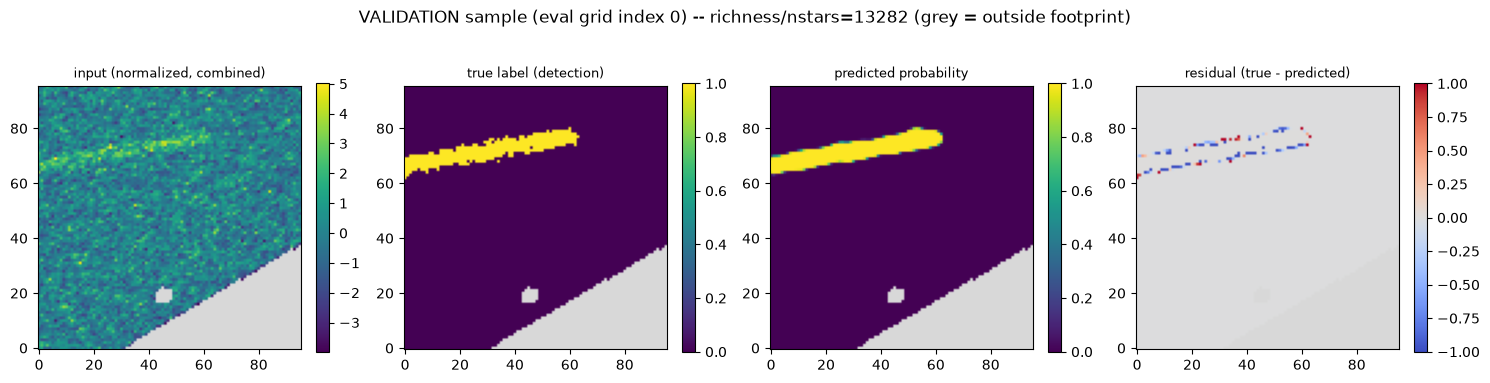

In [11]:
# Change this and re-run the cell to inspect a different validation sample
# (see the markdown above for what the index means).
inspect_idx = 0

sample0 = eval_dataset_norm[inspect_idx]
channels_meta = sample0["metadata"]["channels"]
good_idx = next(
    i
    for i, ch in enumerate(channels_meta)
    if ch["filter"] == "good" and ch["distance_modulus"] == stream_param_cfg["distance_modulus"]
)
valid_mask0 = sample0["valid_mask"]

model.eval()
with torch.no_grad():
    x = torch.from_numpy(sample0["map_stack"]).unsqueeze(0)
    pred0 = model(x)[0].numpy()
residual0 = sample0["label_stack"] - pred0

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(color="0.85")
resid_cmap = plt.get_cmap("coolwarm").copy()
resid_cmap.set_bad(color="0.85")


def _masked(img):
    return np.where(valid_mask0, img, np.nan)


fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, img, title, cm, kwargs in zip(
    axes,
    [
        sample0["map_stack"][good_idx],
        sample0["label_stack"][good_idx],
        pred0[good_idx],
        residual0[good_idx],
    ],
    [
        "input (normalized, combined)",
        "true label (detection)",
        "predicted probability",
        "residual (true - predicted)",
    ],
    [cmap, cmap, cmap, resid_cmap],
    [{}, dict(vmin=0, vmax=1), dict(vmin=0, vmax=1), dict(vmin=-1, vmax=1)],
):
    im = ax.imshow(_masked(img), origin="lower", cmap=cm, **kwargs)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(
    f"VALIDATION sample (eval grid index {inspect_idx}) -- "
    f"richness/nstars={sample0['params']['nstars']} (grey = outside footprint)"
)
plt.tight_layout()
plt.show()

## 7. Evaluate on the grid, compare to the k·σ baseline

`evaluate_on_grid` walks every point of `eval_dataset_multi_norm` and
computes each requested metric per sample, thresholding both `pred` and
`label_stack` at 0.5 for the segmentation metrics -- a natural threshold on
a `{0, 1}` label, not an arbitrary choice the way it would be against a
literal count.

**This grid has `n_eval_replicates` independent realizations per richness
value**, not one: same physical parameters, different placement, window,
orientation and noise. That matters because a single realization's Dice can
land anywhere within a wide spread (§8 shows the extreme case), so
`aggregate_over_replicates` reports each richness's **mean and standard
deviation** instead of one number that reads more precisely than it is.
`<metric>_n` is the number of realizations that actually contributed --
NaN metrics (evaluation.metrics' undefined-ratio convention) drop out per
metric rather than poisoning the group.

`"confusion"` is requested alongside the ratios: it expands into raw
`tp`/`fp`/`tn`/`fn` pixel counts, which say *how* the model is wrong in a
way no ratio does (5 false positives and 5000 can give identical recall).
Invalid pixels are excluded from `tn` rather than counted, which would
otherwise swamp it with the whole out-of-footprint area.

Note the grouping column is `nstars`, not `richness`: `richness` is
resolved to a star count by `resolve_richness_to_nstars` before injection,
so `nstars` is what survives into each sample's `params` (one value per
richness, so the mapping is 1:1).

`baseline_threshold.build_baseline` is a trivial, non-learned comparison
(mean + k·σ on the same `"good"` channel of the *unnormalized* combined
map) -- worth comparing against, though not necessarily worth *beating* at
the bright end, where a real stream is a large, sharp excess a simple
threshold finds easily and the baseline is additionally handed the "good"
channel directly.

In [12]:
results = evaluate_on_grid(
    model,
    eval_dataset_multi_norm,
    metrics=["mse", "dice", "iou", "correlation", "weighted_recall", "confusion"],
)

baseline_dice = []
for idx in results["id"]:
    raw_sample = eval_dataset_multi[idx]  # unnormalized -- real count units
    baseline_pred = build_baseline(raw_sample["map_stack"][good_idx], raw_sample["valid_mask"], k=2.0)
    baseline_dice.append(dice(baseline_pred, raw_sample["label_stack"][good_idx], raw_sample["valid_mask"]))
results["baseline_dice"] = baseline_dice

results[["nstars", "replicate", "dice", "iou", "correlation", "tp", "fp", "fn", "baseline_dice"]]

,nstars,replicate,dice,iou,correlation,tp,fp,fn,baseline_dice
0,13282,0,0.906892,0.829646,0.912439,375,59,18,0.341906
1,13282,1,0.867069,0.765333,0.874700,287,66,22,0.314010
2,13282,2,0.866817,0.764940,0.875260,384,79,39,0.297059
3,13282,3,0.866747,0.764831,0.874742,361,85,26,0.375000
4,13282,4,0.858708,0.752399,0.869515,392,106,23,0.307692
5,5288,0,0.181818,0.100000,0.233588,27,31,212,0.074246
6,5288,1,0.572139,0.400697,0.617676,115,45,127,0.131213
7,5288,2,0.434540,0.277580,0.464600,78,85,118,0.105820
8,5288,3,0.000000,0.000000,0.098605,0,0,109,0.027972
9,5288,4,0.507812,0.340314,0.511183,65,64,62,0.140496


per-richness, aggregated over realizations (mean / std / n):
 nstars  dice_mean  dice_std  dice_n  iou_mean  baseline_dice_mean
   1329   0.000000  0.000000       5  0.000000            0.019117
   2106   0.000000  0.000000       5  0.000000            0.019228
   3337   0.025484  0.037207       5  0.013198            0.069547
   5288   0.339262  0.240627       5  0.223718            0.095949
  13282   0.873247  0.019139       5  0.775430            0.327133

mean network dice over all realizations:  0.248
mean baseline dice over all realizations: 0.106


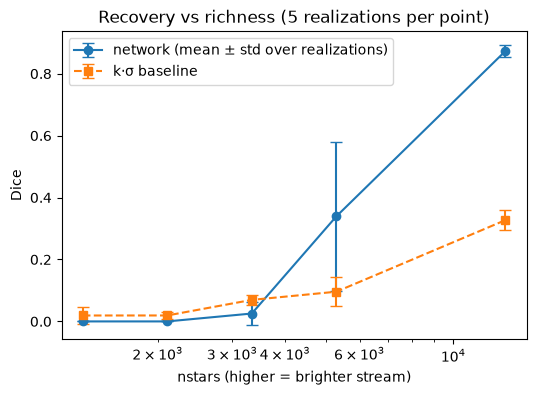

In [13]:
summary = aggregate_over_replicates(
    results,
    metrics=["dice", "iou", "correlation", "baseline_dice", "tp", "fp", "fn"],
    group_by=["nstars"],
)
print("per-richness, aggregated over realizations (mean / std / n):")
print(
    summary[
        ["nstars", "dice_mean", "dice_std", "dice_n", "iou_mean", "baseline_dice_mean"]
    ].to_string(index=False)
)
print()
print(f"mean network dice over all realizations:  {results['dice'].mean():.3f}")
print(f"mean baseline dice over all realizations: {results['baseline_dice'].mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    summary["nstars"], summary["dice_mean"], yerr=summary["dice_std"],
    marker="o", capsize=4, label="network (mean ± std over realizations)",
)
ax.errorbar(
    summary["nstars"], summary["baseline_dice_mean"], yerr=summary["baseline_dice_std"],
    marker="s", linestyle="--", capsize=4, label="k·σ baseline",
)
ax.set_xscale("log")
ax.set_xlabel("nstars (higher = brighter stream)")
ax.set_ylabel("Dice")
ax.set_title(f"Recovery vs richness ({n_eval_replicates} realizations per point)")
ax.legend()
plt.show()

## 8. Does a per-richness eval-grid result hold up across different realizations?

Every point in `eval_dataset`'s grid (§7) is exactly **one** fixed
realization -- one placement, one window (position and orientation), one
noise draw, generated once with that point's own fixed seed and cached
thereafter (see `datasets_and_models`'s "Eval grid: one fixed realization
per point" section in the docs). A metric like "Dice at
surface_brightness=34" is therefore a measurement on a sample size of
one, not an average over the many realizations a stream with those
physical parameters could actually produce -- it does not marginalize
over window position/orientation/noise the way the name suggests.

§7's spread at the faint end is large, so before reading a per-richness
number as "the network detects streams this faint" or "it does not", this
section checks the model directly on several *other* independent
realizations of SB 33 and SB 34, built with different seeds (window
position, orientation and survey noise), everything else held fixed. The
already-trained model is only run, not retrained. `max_pred_at_true` is the
model's highest probability on the true stream's own pixels: it says whether
the model responded at all, independently of the 0.5 threshold.


In [14]:
def _evaluate_realization(richness, seed):
    """Build one fresh, independent realization at a fixed richness with
    the given seed, run the already-trained model on it, and report both
    the thresholded Dice/IoU and the raw (pre-threshold) predicted
    probability at the true positive pixels -- the latter shows how close
    the model got even on realizations where it never crosses 0.5."""
    stream_params = dict(
        morphology="uniform", richness=richness, width=0.2, length=8.0,
        distance_modulus=stream_param_cfg["distance_modulus"], age=12.5, z=0.0002,
    )
    sample = injector.inject_single_stream(stream_params, np.random.default_rng(seed))
    prepared = eval_transform(
        {
            "map_stack": sample.map_stack,
            "label_stack": sample.label_stack,
            "valid_mask": sample.valid_mask,
            "params": sample.params,
            "metadata": sample.metadata,
        }
    )
    model.eval()
    with torch.no_grad():
        x = torch.from_numpy(prepared["map_stack"]).unsqueeze(0)
        pred = model(x)[0].numpy()
    label = sample.label_stack[good_idx]
    valid = sample.valid_mask
    pred_good = pred[good_idx]
    n_true_pos_px = int((label > 0.5).sum())
    max_pred_at_true = float(pred_good[label > 0.5].max()) if n_true_pos_px > 0 else float("nan")
    return dict(
        richness=richness,
        seed=seed,
        nstars=sample.params["nstars"],
        n_true_pos_px=n_true_pos_px,
        max_pred_at_true=max_pred_at_true,
        dice=dice(pred_good, label, valid),
        iou=iou(pred_good, label, valid),
    )


diagnostic_rows = []
for seed in range(1, 9):
    diagnostic_rows.append(_evaluate_realization(34.0, seed))
    diagnostic_rows.append(_evaluate_realization(33.0, seed))

diagnostic_df = pd.DataFrame(diagnostic_rows)
diagnostic_df

,richness,seed,nstars,n_true_pos_px,max_pred_at_true,dice,iou
0,34.0,1,2106,55,0.000922,0.000000,0.000000
1,33.0,1,5288,152,0.728501,0.025806,0.013072
2,34.0,2,2106,49,0.000971,0.000000,0.000000
3,33.0,2,5288,143,0.998496,0.483607,0.318919
4,34.0,3,2106,67,0.000908,0.000000,0.000000
5,33.0,3,5288,100,1.000000,0.521073,0.352332
6,34.0,4,2106,41,0.000911,0.000000,0.000000
7,33.0,4,5288,217,0.999998,0.395062,0.246154
8,34.0,5,2106,39,0.000930,0.000000,0.000000
9,33.0,5,5288,240,0.999980,0.429412,0.273408


### 8.1 Reading the result

**SB 33 is the detection edge, and the model responds on every draw.** Over 8
independent realizations with identical physical parameters, `max_pred_at_true`
is 0.73 or above on all of them, and above 0.998 on seven. What varies is how
much of the track is recovered: Dice ranges from 0.03 to 0.70. The earlier
version of this notebook (1200 training windows, trained on SB 31-34) was
bimodal here — half the realizations got no response at all — and training on
4800 windows over SB 32-34.5 removed that.

**SB 34 still gets no response**: `max_pred_at_true` is about 0.0009 on every
realization, far below any useful threshold, even though SB 34 is inside the
training range. One model at this budget does not reach it; the hyperparameter
experiment (docs: "Experiments and tests") shows that averaging several
trainings is what recovers part of SB 34.

This is the per-realization detail behind the averages. A single realization
per richness would report anything between a healthy Dice and near zero at
SB 33, purely from which draw the grid happened to pin.

## 9. The end product: HEALPix maps of input, label and prediction

Everything above works in *windows* -- small gnomonic images, which is what
the network consumes. A stream search works the other way round: the survey
map exists first, and windows are something you impose on it. This section
runs that direction end to end and produces the three maps that actually
matter, all on the same HEALPix grid:

1. **input** -- background + injected stream, as observed through the
   "good" matched filter,
2. **label** -- the true detection mask,
3. **prediction** -- the model's per-pixel probability.

Three pieces make it work:

- `injector.inject_stream_full_sky` returns the same channels
  `inject_single_stream` builds, but as **full-sky maps instead of one
  crop** -- the simulated stand-in for a real survey map.
- `tile_footprint(..., stride_deg=...)` covers the region with
  **overlapping** windows, so every sky pixel is seen by more than one.
- `stitch_windows_to_healpix` puts the per-window outputs back on the sky,
  resolving overlaps by keeping the value from the window where each pixel
  sits **furthest from an edge** -- the U-Net "overlap-tile" strategy --
  rather than averaging them.

Averaging would be the obvious alternative and is the wrong one here: the
output is a probability meant to be thresholded by whoever reads it, and
the mean of 0.9 and 0.1 is 0.5, which is a different claim from a genuine
0.5. Every value below is one the model actually produced, taken from the
window that saw that pixel with the most surrounding context.

In [15]:
# A stream injected into the full sky -- no window chosen yet.
healpix_params = dict(
    morphology="uniform",
    richness=32.5,  # a richness the model handles well (see §7)
    width=stream_param_cfg["width"],
    length=stream_param_cfg["length"],
    distance_modulus=stream_param_cfg["distance_modulus"],
    age=stream_param_cfg["age"],
    z=stream_param_cfg["z"],
)
full_sky = injector.inject_stream_full_sky(healpix_params, np.random.default_rng(SEED))
nside = matched_filter_cfg["pixelization"]["nside"]

# Overlapping tiles (stride = half a window) around the stream, so the
# stitcher has a real choice of source per sky pixel.
tiles = tiles_around_stream(full_sky, channel=good_idx, pix=pix, stride_fraction=0.5)
print(f"{len(tiles)} overlapping tiles covering the stream's neighbourhood")

# Tile -> crop -> normalize -> predict -> stitch. The same library function
# §10 uses for every realization, so this picture and those scores come from
# one implementation.
maps = predict_footprint(
    model, full_sky, tiles, pix, eval_transform, channel=good_idx,
    count_threshold=count_threshold,
)
input_hp, label_hp, pred_hp, covered = (
    maps["input"], maps["label"], maps["prediction"], maps["covered"]
)
centre_vec = np.mean(
    np.array(hp.pix2vec(nside, np.flatnonzero(full_sky["stream_raw_full"][good_idx] > 0))).T,
    axis=0,
)
centre_vec /= np.linalg.norm(centre_vec)
print(f"stitched onto {covered.sum()} HEALPix pixels "
      f"(nside={nside}, {hp.nside2resol(nside, arcmin=True):.1f} arcmin/pixel)")

11 overlapping tiles covering the stream's neighbourhood
stitched onto 45101 HEALPix pixels (nside=512, 6.9 arcmin/pixel)


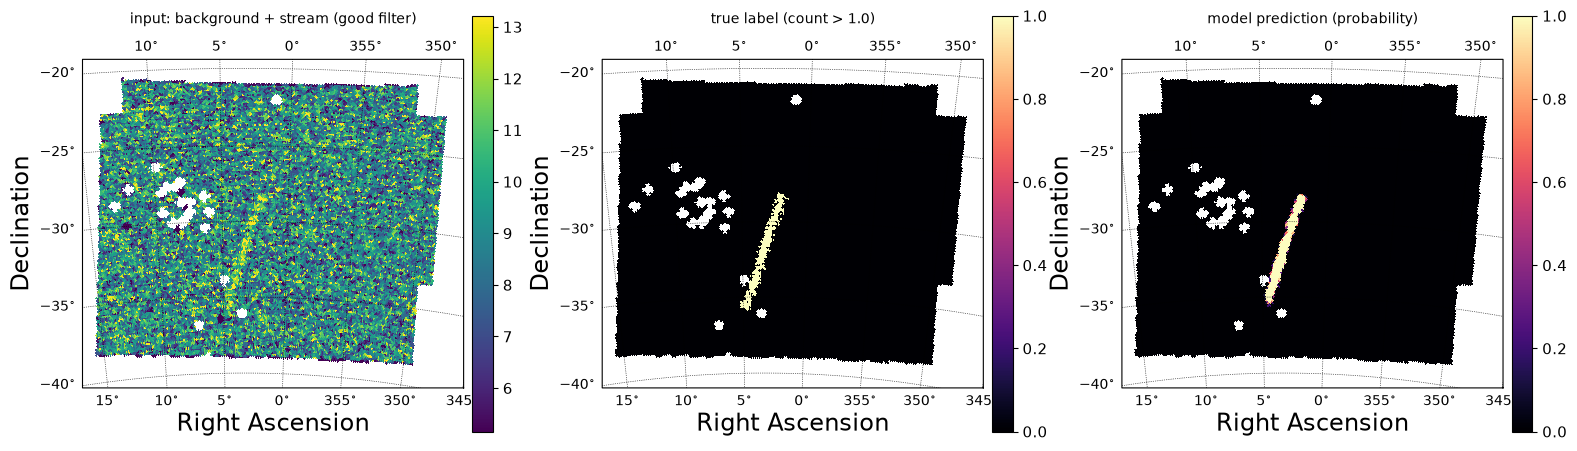

HEALPix pixels above 0.5: 352 predicted, 327 true, 274 overlapping


In [16]:
centre_ra, centre_dec = hp.vec2ang(centre_vec, lonlat=True)

# skyproj rather than healpy's gnomview: `zoom=True` crops automatically to
# the pixels that actually carry data, so the panels frame the footprint
# without hand-tuned centres or sizes, and unseen pixels stay blank instead
# of being painted as a value.
fig, axes = plt.subplots(1, 3, figsize=(19, 5.4))
for ax, (image, title, style) in zip(
    axes,
    [
        (input_hp, "input: background + stream (good filter)", dict(cmap="viridis")),
        (label_hp, f"true label (count > {count_threshold})",
         dict(cmap="magma", vmin=0, vmax=1)),
        (pred_hp, "model prediction (probability)",
         dict(cmap="magma", vmin=0, vmax=1)),
    ],
):
    # UNSEEN is skyproj's documented "no data" sentinel (NaN also works in
    # 2.6.1, but the sentinel is the contract). This covers both kinds of
    # gap at once: sky no window reached, and pixels outside the footprint.
    shown = np.where(np.isfinite(image) & covered, image, hp.UNSEEN)
    sp = skyproj.GnomonicSkyproj(
        ax=ax, lon_0=float(centre_ra[0]), lat_0=float(centre_dec[0])
    )
    sp.draw_hpxmap(shown, zoom=True, **style)
    sp.draw_colorbar(location="right", fraction=0.10, pad=0.02)
    sp.ax.set_title(title, fontsize=10, pad=26)
plt.show()

detected = covered & np.isfinite(pred_hp) & (pred_hp > 0.5)
truth = covered & np.isfinite(label_hp) & (label_hp > 0.5)
print(f"HEALPix pixels above 0.5: {int(detected.sum())} predicted, "
      f"{int(truth.sum())} true, {int((detected & truth).sum())} overlapping")

These three are directly comparable: every panel went through the *same*
tiling, cropping and stitching, so any difference is the model's, not an
artifact of how the pictures were made. Blank areas are sky no window
reached, or gaps inside the survey footprint -- those pixels are `NaN`/
`UNSEEN`, never `0.0`, since a zero there would read as a confident
non-detection rather than "no data", and `skyproj` leaves them unpainted
rather than colouring them as a value.

**Worth looking at rather than just scoring.** The prediction follows the
stream's track closely, and the rest of the field is clean: no scattered
false alarms, including on the rims of footprint holes, where a sharp edge in
the local star counts can look like a stream. (An earlier version of this
notebook, trained with plain Dice, flagged many such pixels; see §10.1.)

This is the shape the full-survey search will take: swap the injected
stream for a real map, tile the whole footprint instead of one
neighbourhood, and the prediction panel is the candidate map to threshold.

## 10. Where does detection stop? Confusion matrix and detection rates vs surface brightness

§9 showed one stream. One realization says little -- earlier versions of
this notebook reported both a confident `0.000` and a later `0.039` for the
same configuration, purely from which single realization was drawn. So here
every point is an average over **many independent full-sky realizations**:
different stream population, placement, orientation and survey noise each
time, each one tiled, predicted and stitched exactly as in §9.

Everything is scored **per pixel on the stitched HEALPix map**, counting
only sky a window actually covered. Two views:

1. **Confusion matrix** per surface brightness, row-normalized so each row
   sums to one: of the pixels that truly are stream, what fraction were
   *found* vs *missed*; of the pixels that truly are background, what
   fraction were *false alarms* vs *correctly rejected*. Rates rather than
   counts, because stream pixels are a tiny minority of any map -- raw
   counts would be dominated by background whatever the model did.
2. **Found fraction vs background false-alarm rate, against surface
   brightness**, mean ± std over realizations, with the training range
   shaded. The missed fraction is just `1 - found`, so it is not drawn.
   What the found fraction has to be read against is the background: half
   the stream pixels found means nothing if background pixels are flagged
   just as often. So the lower panel shows the fraction of background
   pixels flagged as stream, both on the sky with the stream and on **the
   same tiles with the stream removed** (`no_stream_control`). The
   no-stream line is the floor set by the background alone; the gap above
   it is what the stream itself adds.

**Read the faint end carefully.** Past some surface brightness *no* pixel
exceeds `count_threshold`, so there is no true stream pixel left to find.
That point is marked separately rather than drawn as zero: "the label
vanished" and "the model stopped detecting" are different statements, and
only the second is about the model. `n_true_pixels` in the table below is
what tells them apart.

**One caveat on the false-alarm rate.** Tiles are placed around each
injected stream, so false alarms are measured *near* a stream rather than
over the whole footprint. That keeps the evaluated area identical across
surface brightness, which is what a controlled comparison needs, but it is
not a survey-wide false-positive rate -- that needs the whole footprint
tiled, which is what multi-stream populations will bring.

In [17]:
import warnings

# Bracket the training range (31-34) and extend fainter, to find the edge.
surface_brightness_grid = [30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0]
n_footprint_realizations = 30

param_sets = [dict(healpix_params, richness=sb) for sb in surface_brightness_grid]
with warnings.catch_warnings():
    # streamobs scatters faint stars in flux space; a star pushed below zero
    # flux gets a NaN magnitude (log10 of a negative) and is simply not
    # detected. Expected, and repeated for every realization, so muted here.
    warnings.filterwarnings("ignore", "invalid value encountered in log10")
    footprint_results = evaluate_footprint_realizations(
        model,
        injector,
        eval_transform,
        param_sets,
        n_realizations=n_footprint_realizations,
        channel=good_idx,
        seed=SEED,
        # Counts above every threshold of THRESHOLD_GRID, so §11 can show any
        # threshold without re-running the model.
        thresholds=THRESHOLD_GRID,
    )

detection = aggregate_over_replicates(
    footprint_results,
    metrics=["tpr", "fnr", "fpr", "tnr", "precision", "fpr_no_stream", "n_true_pixels"],
    group_by=["richness"],
)
print(f"{len(footprint_results)} realizations "
      f"({n_footprint_realizations} per surface brightness)\n")
print(
    detection[
        ["richness", "n_true_pixels_mean", "tpr_mean", "tpr_std", "tpr_n",
         "fpr_mean", "fpr_no_stream_mean", "precision_mean"]
    ].to_string(index=False, float_format=lambda v: f"{v:.3g}")
)

210 realizations (30 per surface brightness)

 richness  n_true_pixels_mean  tpr_mean  tpr_std  tpr_n  fpr_mean  fpr_no_stream_mean  precision_mean
       30                 550     0.943   0.0119     30   0.00187                   0           0.927
       31                 516     0.966   0.0116     30   0.00286                   0           0.887
       32                 363     0.929   0.0319     30   0.00365                   0           0.803
       33                 186     0.382    0.198     30   0.00228                   0           0.615
       34                46.1   0.00294   0.0161     30  1.56e-05                   0            0.25
       35                6.57         0        0     30         0                   0             NaN
       36               0.433         0        0     10         0                   0             NaN


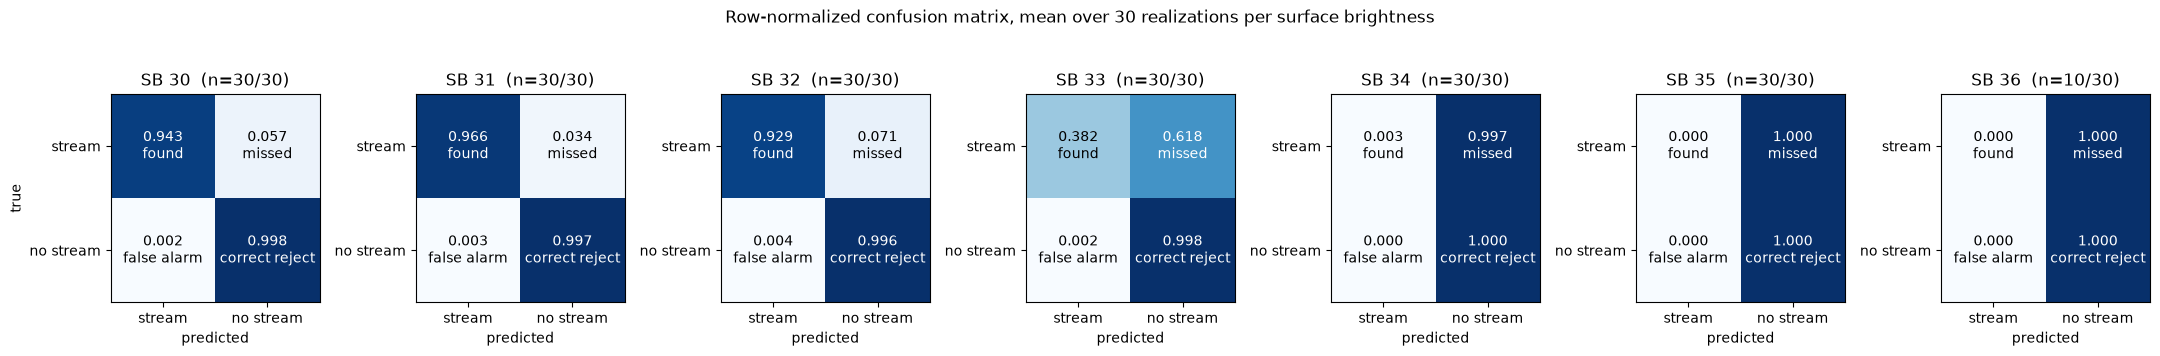

In [18]:
fig, axes = plt.subplots(1, len(surface_brightness_grid),
                         figsize=(3.1 * len(surface_brightness_grid), 3.4))
for ax, (_, row) in zip(axes, detection.sort_values("richness").iterrows()):
    plot_confusion_matrix(
        {rate: row[f"{rate}_mean"] for rate in ("tpr", "fnr", "fpr", "tnr")},
        ax=ax,
        title=f"SB {row['richness']:.0f}  (n={int(row['tpr_n'])}/{int(row['n_true_pixels_n'])})",
    )
    if ax is not axes[0]:
        ax.set_ylabel("")
fig.suptitle(
    f"Row-normalized confusion matrix, mean over {n_footprint_realizations} "
    "realizations per surface brightness", y=1.03,
)
plt.tight_layout()
plt.show()

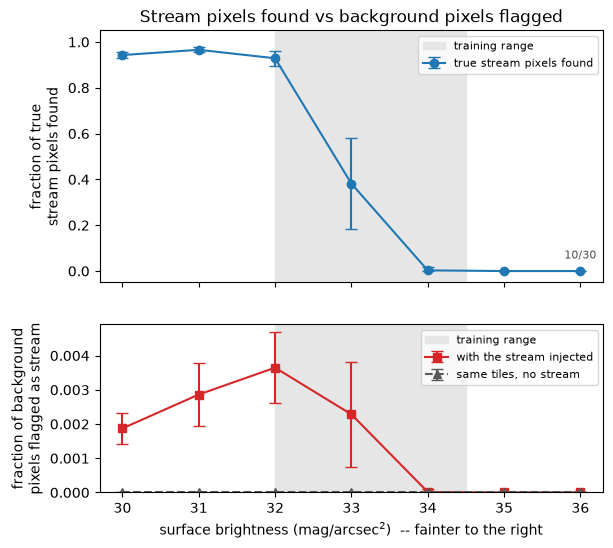

half the true stream pixels are found down to SB ~ 32.78 mag/arcsec^2


In [19]:
ax_found, ax_false = plot_detection_rates(
    detection, "richness",
    training_range=(min(stream_param_cfg["richness"]), max(stream_param_cfg["richness"])),
)
ax_false.set_xlabel("surface brightness (mag/arcsec$^2$)  -- fainter to the right")
ax_found.set_title("Stream pixels found vs background pixels flagged")
plt.show()

# Where detection stops: the faintest surface brightness at which, on
# average, at least half of the true stream pixels are still found --
# interpolated between grid points, using only points with true pixels.
defined = detection.dropna(subset=["tpr_mean"]).sort_values("richness")
sb, tpr = defined["richness"].to_numpy(), defined["tpr_mean"].to_numpy()
crossing = np.flatnonzero((tpr[:-1] >= 0.5) & (tpr[1:] < 0.5))
if crossing.size:
    i = crossing[0]
    edge = sb[i] + (0.5 - tpr[i]) * (sb[i + 1] - sb[i]) / (tpr[i + 1] - tpr[i])
    print(f"half the true stream pixels are found down to SB ~ {edge:.2f} mag/arcsec^2")
elif (tpr >= 0.5).all():
    print(f"at least half the true pixels are found at every SB where a label exists "
          f"(down to SB {sb.max():.0f}); the limit is set by the label vanishing, "
          f"not by the model")
else:
    print("fewer than half the true pixels are found even at the brightest SB tested")

vanished = detection.loc[detection["tpr_mean"].isna(), "richness"].tolist()
if vanished:
    print(f"no true stream pixels at all (label vanished) at SB: {vanished}")

### 10.1 Reading the result

**Found fraction.** At threshold 0.5, 94% of the true stream pixels are found
at SB 30, 93% at SB 32, 38% at SB 33 and essentially none at SB 34 (0.3%).
Half of the stream is found down to SB ≈ 32.8.

**False alarms come from the stream, not from the background.** On the sky
with the stream, 0.2 to 0.4% of the background pixels around it are flagged.
With the stream removed, on exactly the same tiles, not a single pixel is
flagged in any of the 210 realizations: the flagged background pixels are ones
the stream itself provoked, typically just beside its track. Precision (the
fraction of flagged pixels that really are stream) is 0.93 at SB 30, 0.80 at
SB 32 and 0.62 at SB 33.

**What changed with the loss.** An earlier version of this notebook was
trained with plain Dice at batch 2. It flagged about 0.9% of the background at
every surface brightness, even with no stream at all, and those false alarms
sat on the same sky pixels from one realization to the next. The cause is Dice
itself: on a window with no stream, Dice loss is about 1 whatever the
prediction, so nothing teaches the model to predict low there. Batch Dice pools
the loss over the batch, so such a window does count (§4).

**What changed with the training set.** This model is trained on 4800 windows
over SB 32-34.5, where the previous version used 1200 windows over SB 31-34.
At the same threshold it finds 38% of the stream pixels at SB 33 instead of
12%. Both numbers are one training each, and the spread between trainings at
this surface brightness is wide — the hyperparameter experiment (docs:
"Experiments and tests") measures it, and concludes that averaging several
trainings is the reliable way to gain at the faint end.

## 11. Completeness, contamination and contrast

§10's rates depend on how much background was scored around each stream. The
view used to compare models (docs: "Experiments and tests") does not. With
counts summed over the realizations of one surface brightness, at a
probability threshold $t$:

- $S_t$ true stream pixels, of which $S_s$ are classified as stream;
- $B_t$ true background pixels, of which $B_s$ are classified as stream;
- **completeness** $C = S_s/S_t$: the fraction of the stream found;
- **contamination** $F = B_s/B_t$: the fraction of the background flagged;
- **contrast** $C/F$: how many times more likely a stream pixel is to be
  flagged than a background pixel. $C/F = 1$ means the stream cannot be told
  from the background, whatever $C$ is.

The threshold is a free choice made after training. The lines below show how
it moves the three quantities; 0.5 (thick) is the reference used to compare
models. Hollow points: fewer than 20 stream pixels found, too few to measure
$C$ or $C/F$.


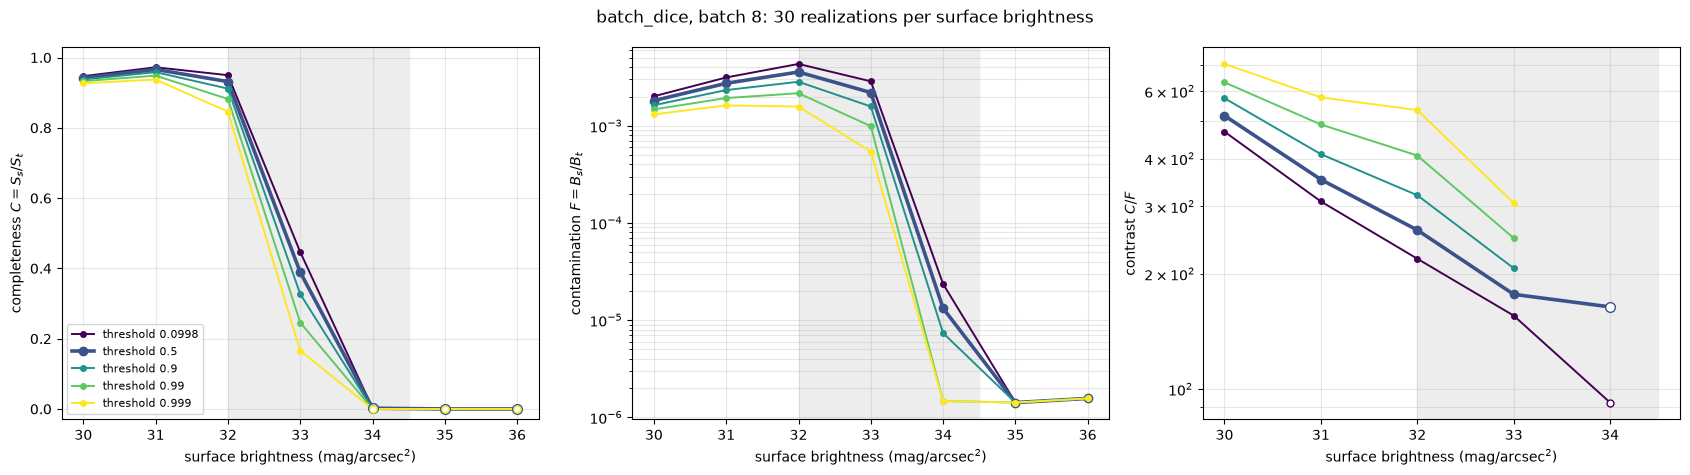

 richness   S_s   S_t  B_s    B_t  completeness  contamination  contrast
       30 15544 16505 1180 648731         0.942        0.00182       518
       31 14946 15470 1909 696521         0.966        0.00274       353
       32 10150 10895 2511 701297         0.932        0.00358       260
       33  2173  5583 1425 647110         0.389         0.0022       177
       34     3  1384    9 680452       0.00217       1.32e-05       164
       35     0   197    0 706532             0       1.42e-06       NaN
       36     0    13    0 640486             0       1.56e-06       NaN


In [20]:
metrics_by_sb = detection_metrics(
    footprint_results,
    THRESHOLD_GRID,
    group_by=["richness"],
    at=(0.1, 0.5, 0.9, 0.99, 0.999),
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
plot_detection_metrics(
    metrics_by_sb,
    param="richness",
    axes=axes,
    highlight=0.5,
    training_range=(min(stream_param_cfg["richness"]), max(stream_param_cfg["richness"])),
)
for ax in axes:
    ax.set_xlabel("surface brightness (mag/arcsec$^2$)")
fig.suptitle(
    f"{train_cfg['loss_name']}, batch {train_cfg['batch_size']}: "
    f"{n_footprint_realizations} realizations per surface brightness"
)
plt.tight_layout()
plt.show()

at_reference = metrics_by_sb[np.isclose(metrics_by_sb["threshold"], 0.5)]
print(
    at_reference[["richness", "S_s", "S_t", "B_s", "B_t", "completeness", "contamination", "contrast"]]
    .to_string(index=False, float_format=lambda v: f"{v:.3g}")
)


## Summary

| Piece | Module |
|---|---|
| Background + matched filters + injector | `background.py`, `matched_filter.py`, `injector.py` (same as `create_data.ipynb`) |
| On-the-fly training samples + replicated eval grid | `datasets/stream_map_dataset.py`, `config.build_eval_grid` |
| Normalization + augmentation | `datasets/transforms.py` |
| Model (`head="sigmoid"`) | `models/unet.py` |
| Loss (`batch_dice`) | `models/losses.py` |
| Training loop + checkpointing | `training/plain_runner.py` |
| Window metrics, baseline, replicate aggregation | `evaluation/metrics.py`, `evaluation/baseline_threshold.py`, `evaluation/completeness_purity.py` |
| HEALPix maps, footprint scoring, completeness / contamination / contrast | `matched_filter.py` (stitching), `evaluation/footprint.py` |

Configuration: `label_policy="stream_detection"` with `count_threshold=1.0`,
training on surface brightness 32-34.5, magnitude range 16-24.5 in g and r
(`clipping_cfg`), 4800 training windows in batches of 8, batch Dice loss,
`background_fraction=0.05`. The background catalog is explicitly seeded (§1).
The loss, batch size and background fraction come from the loss-selection
experiment; the training range and length from the hyperparameter experiment
(docs: "Experiments and tests").

**Per window (§7, threshold 0.5, 5 realizations per surface brightness):**

| surface brightness | nstars | Dice | IoU | baseline Dice |
|---|---|---|---|---|
| 32 | 13282 | 0.873 ± 0.019 | 0.775 | 0.327 |
| 33 |  5288 | 0.339 ± 0.241 | 0.224 | 0.096 |
| 33.5 | 3337 | 0.025 ± 0.037 | 0.013 | 0.070 |
| 34 |  2106 | 0.000 | 0.000 | 0.019 |
| 34.5 | 1329 | 0.000 | 0.000 | 0.019 |

**On the HEALPix map (§10-11, threshold 0.5, 30 realizations per surface
brightness):**

| surface brightness | completeness $C$ | contamination $F$ | contrast $C/F$ |
|---|---|---|---|
| 30 | 0.94 | 1.8e-3 | 518 |
| 31 | 0.97 | 2.7e-3 | 353 |
| 32 | 0.93 | 3.6e-3 | 260 |
| 33 | 0.39 | 2.2e-3 | 177 |
| 34 | 0.002 | 1.3e-5 | 164 |

- **Streams brighter than SB 33 are found cleanly**: over 90% of their pixels,
  with a few 1e-3 of the background flagged, and the network beats the k·σ
  baseline by a wide margin.
- **SB 33 is the detection edge**: every realization responds (§8), 39% of the
  pixels found at threshold 0.5. SB 34 gets essentially no response from this
  single model.
- **The threshold is a tuning knob, not a fixed part of the model** (§11):
  lower it for completeness at the faint end, raise it for cleaner maps. Two
  models should be compared at the same false-alarm rate rather than at the
  same threshold — that comparison is what the hyperparameter experiment uses.

**Still open:** tuning the threshold, and checking it on skies not used to
choose it; averaging several trainings into one prediction, which is what the
hyperparameter experiment found recovers SB 34; widening the stream parameters
(distance modulus, width, length, age, metallicity); and several streams per
footprint. See "Experiments and tests" in the docs.